# PyEED Python API Tutorial

This notebook demonstrates how to query the PyEED database using:
1. **Python API** - Using the model layer (`BaseNode` methods like `get_filtered`, `get_related`)
2. **Native Cypher queries** - Direct Neo4j queries for complex operations
3. **Vector search** - Using Milvus for protein embeddings
4. **Data analysis** - Combining data into pandas DataFrames and visualizing with UMAP


In [1]:
# Required for running async code in Jupyter notebooks
import nest_asyncio

nest_asyncio.apply()


In [2]:
# Core imports
import asyncio
import pandas as pd
import numpy as np
from rich import print

# PyEED imports
from pyeed.db.neo4j import get_async_driver
from pyeed.db.milvus import get_async_milvus_client
from pyeed.ingest.model import Protein, Reaction, Molecule, Taxon, Annotation, GOAnnotation
from pyeed.queries import get_vectors


## Setup Database Connections

We use convenience methods to get database drivers. These read connection details from environment variables (`NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASSWORD`, `MILVUS_URL`).


In [3]:
# Get database drivers
neo4j_driver = get_async_driver()
milvus_client = get_async_milvus_client()

print("[green]✓ Connected to Neo4j and Milvus[/green]")


✓ Connected to Neo4j and Milvus

---
# Chapter 1: Python API Queries

The PyEED model layer provides several methods for querying the database:

| Method | Description |
|--------|-------------|
| `get(id=...)` | Get a single node by its indexed field |
| `get(ids=[...])` | Get multiple nodes by their indexed fields |
| `get_filtered(...)` | Get nodes with filters and range queries |
| `get_related(...)` | Get related nodes via relationships |
| `get_all(limit=...)` | Get all nodes with pagination |
| `count()` | Count all nodes of this type |


## 1.1 Querying Proteins

### Get a single protein by ID


In [4]:
# Get a single protein by UniProt ID
protein = await Protein.get(neo4j_driver, id="P12345")

if protein:
    print(f"[bold]Protein:[/bold] {protein.id}")
    print(f"  Name: {protein.name}")
    print(f"  Sequence length: {protein.seq_length}")
    print(f"  Molecular weight: {protein.mol_weight}")
    print(f"  EC numbers: {protein.ec_numbers}")
    print(f"  Sequence (first 50 aa): {protein.sequence[:50]}...")
else:
    print("[red]Protein not found[/red]")


Protein: P12345

Name: Aspartate aminotransferase, mitochondrial

Sequence length: 430

Molecular weight: None

EC numbers: ['2.6.1.1', '2.6.1.7']

Sequence (first 50 aa): MALLHSARVLSGVASAFHPGLAAAASARASSWWAHVEMGPPDPILGVTEA...

### Get multiple proteins by IDs


In [5]:
# Get multiple proteins by their UniProt IDs
protein_ids = ["P12345", "P0CW62", "Q9Y6K1"]
proteins = await Protein.get(neo4j_driver, ids=protein_ids)

print(f"[bold]Found {len(proteins)} proteins:[/bold]")
for p in proteins:
    print(f"  • {p.id}: {p.name} (length: {p.seq_length})")


Found 3 proteins:

• P12345: Aspartate aminotransferase, mitochondrial (length: 430)

• P0CW62: S-adenosylmethionine synthase (length: 405)

• Q9Y6K1: DNA (cytosine-5)-methyltransferase 3A (length: 912)

### Filter proteins by sequence length range


In [6]:
# Get proteins with sequence length between 100 and 200 amino acids
filtered_proteins = await Protein.get_filtered(neo4j_driver, ranges={"seq_length": (100, 200)})

print(f"[bold]Found {len(filtered_proteins)} proteins with seq_length 100-200:[/bold]")
for p in filtered_proteins[:5]:  # Show first 5
    print(f"  • {p.id}: {p.name} (length: {p.seq_length})")
if len(filtered_proteins) > 5:
    print(f"  ... and {len(filtered_proteins) - 5} more")


Found 127097 proteins with seq_length 100-200:

• A0A841SFL2: methionine adenosyltransferase (length: 149)

• A0A843TUS1: None (length: 184)

• A0A850QUU3: None (length: 180)

• A0A852BTF9: methionine adenosyltransferase (length: 200)

• A0A851QLW5: methionine adenosyltransferase (length: 200)

... and 127092 more

### Combined filtering: IDs + range


In [7]:
# Get specific proteins with additional range filter
# This fetches proteins by ID and filters by sequence length
combined = await Protein.get_filtered(
    neo4j_driver,
    ids=["P12345", "P0CW62"],
    ranges={"seq_length": (410, None)},  # At least 410 aa
)

print(f"[bold]Proteins with seq_length >= 410:[/bold]")
for p in combined:
    print(f"  • {p.id}: length={p.seq_length}")


Proteins with seq_length >= 410:

• P12345: length=430

## 1.2 Getting Related Nodes

The `get_related` method retrieves nodes connected by relationships. It supports:
- Single ID → returns `list[TargetType]`
- Multiple IDs → returns `dict[str, list[TargetType]]`


### Get organism for a protein (Protein → Taxon)


In [8]:
# Get the organism that a protein originates from
# Relationship: (Protein)-[:ORIGINATES_FROM]->(Taxon)
organisms = await Protein.get_related(Taxon, driver=neo4j_driver, id="P12345", direction="out")

if organisms:
    org = organisms[0]  # One-to-one relationship
    print(f"[bold]Organism for P12345:[/bold]")
    print(f"  Taxon ID: {org.id}")
    print(f"  Scientific name: {org.scientific_name}")
    print(f"  Rank: {org.rank}")
else:
    print("[yellow]No organism found[/yellow]")


Organism for P12345:

Taxon ID: 9986

Scientific name: Oryctolagus cuniculus

Rank: species

### Get reactions catalyzed by a protein (Protein → Reaction)


In [9]:
# Get reactions that a protein catalyzes
# Relationship: (Protein)-[:CATALYZES]->(Reaction)
reactions = await Protein.get_related(
    Reaction, driver=neo4j_driver, id="P12345", rel_type="CATALYZES", direction="out"
)

print(f"[bold]Reactions catalyzed by P12345:[/bold]")
for rxn in reactions:
    print(f"  • {rxn.id}: {rxn.description} (reversible: {rxn.reversible})")


Reactions catalyzed by P12345:

• RHEA:65560: L-kynurenine + 2-oxoglutarate = kynurenate + L-glutamate + H2O (reversible: True)

• RHEA:21824: L-aspartate + 2-oxoglutarate = oxaloacetate + L-glutamate (reversible: True)

### Batch query: organisms for multiple proteins


In [10]:
# Get organisms for multiple proteins at once
# Returns a dict mapping protein ID to list of organisms
protein_ids = ["P12345", "P0CW62"]

organisms_batch = await Protein.get_related(
    Taxon, driver=neo4j_driver, ids=protein_ids, direction="out"
)

print(f"[bold]Organisms for multiple proteins:[/bold]")
for pid, orgs in organisms_batch.items():
    if orgs:
        print(f"  {pid}: {orgs[0].scientific_name}")
    else:
        print(f"  {pid}: [yellow]No organism[/yellow]")


Organisms for multiple proteins:

P12345: Oryctolagus cuniculus

P0CW62: Methanococcus maripaludis

## 1.3 Querying Reactions


In [11]:
# Get a reaction by RHEA ID
reaction = await Reaction.get(neo4j_driver, id="RHEA:21080")

if reaction:
    print(f"[bold]Reaction:[/bold] {reaction.id}")
    print(f"  Description: {reaction.description}")
    print(f"  Reversible: {reaction.reversible}")
else:
    print("[red]Reaction not found[/red]")


Reaction: RHEA:21080

Description: L-methionine + ATP + H2O = S-adenosyl-L-methionine + phosphate + diphosphate

Reversible: True

### Get substrates and products of a reaction (Reaction → Molecule)


In [12]:
# Get substrates (Reaction)-[:HAS_SUBSTRATE]->(Molecule)
substrates = await Reaction.get_related(
    Molecule, driver=neo4j_driver, id="RHEA:21080", rel_type="HAS_SUBSTRATE", direction="out"
)

# Get products (Reaction)-[:HAS_PRODUCT]->(Molecule)
products = await Reaction.get_related(
    Molecule, driver=neo4j_driver, id="RHEA:21080", rel_type="HAS_PRODUCT", direction="out"
)

print(f"[bold]Substrates of RHEA:21080:[/bold]")
for mol in substrates:
    smiles_preview = (
        mol.smiles[:30] + "..." if mol.smiles and len(mol.smiles) > 30 else mol.smiles or "N/A"
    )
    print(f"  • {mol.name} (SMILES: {smiles_preview})")

print(f"\n[bold]Products of RHEA:21080:[/bold]")
for mol in products:
    smiles_preview = (
        mol.smiles[:30] + "..." if mol.smiles and len(mol.smiles) > 30 else mol.smiles or "N/A"
    )
    print(f"  • {mol.name} (SMILES: {smiles_preview})")


Substrates of RHEA:21080:

• ATP(4-) (SMILES: Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO...)

• L-methionine zwitterion (SMILES: CSCC[C@H]([NH3+])C(=O)[O-])

• water (SMILES: [H]O[H])

Products of RHEA:21080:

• hydrogenphosphate (SMILES: O=P([O-])([O-])O)

• S-adenosyl-L-methionine zwitterion (SMILES: C[S+](CC[C@H]([NH3+])C(=O)[O-]...)

• diphosphate(3-) (SMILES: O=P([O-])([O-])OP(=O)([O-])O)

### Get proteins that catalyze a reaction (reverse relationship)


In [13]:
# Get proteins that catalyze this reaction
# Relationship: (Protein)-[:CATALYZES]->(Reaction)
# We query from Reaction with direction="in" to get the Proteins
catalyzing_proteins = await Reaction.get_related(
    Protein,
    driver=neo4j_driver,
    id="RHEA:21080",
    rel_type="CATALYZES",
    direction="in",  # Incoming relationship
)

print(f"[bold]Proteins catalyzing RHEA:21080:[/bold]")
for p in catalyzing_proteins[:10]:  # Show first 10
    print(f"  • {p.id}: {p.name}")
if len(catalyzing_proteins) > 10:
    print(f"  ... and {len(catalyzing_proteins) - 10} more")


Proteins catalyzing RHEA:21080:

• A0A0B4F7V8: S-adenosylmethionine synthase

• P0CW62: S-adenosylmethionine synthase

• C5A4B7: S-adenosylmethionine synthase

• Q8PWS4: S-adenosylmethionine synthase

...

• A6VHQ4: S-adenosylmethionine synthase

• Q5JF22: S-adenosylmethionine synthase

• Q12WC8: S-adenosylmethionine synthase

• B6YUL1: S-adenosylmethionine synthase

... and 26716 more

## 1.4 Counting Nodes


In [14]:
# Count nodes of each type
protein_count = await Protein.count(neo4j_driver)
reaction_count = await Reaction.count(neo4j_driver)
molecule_count = await Molecule.count(neo4j_driver)
taxon_count = await Taxon.count(neo4j_driver)

print("[bold]Node counts:[/bold]")
print(f"  Proteins:  {protein_count:,}")
print(f"  Reactions: {reaction_count:,}")
print(f"  Molecules: {molecule_count:,}")
print(f"  Taxa:      {taxon_count:,}")


Node counts:

Proteins:  1,620,714

Reactions: 13,186

Molecules: 9,326

Taxa:      91,712

---
# Chapter 2: Native Cypher Queries

For complex queries, you can use native Cypher. This gives you full control over the query structure.


In [15]:
# Helper function to run Cypher queries
async def run_cypher(driver, query: str, params: dict = None):
    """Execute a Cypher query and return results as list of dicts."""
    async with driver.session() as session:
        result = await session.run(query, params or {})
        return [dict(record) async for record in result]


### 2.1 Get a protein by ID (equivalent to `Protein.get(id=...)`)


In [16]:
# Cypher equivalent of Protein.get(id="P12345")
query = """
MATCH (p:Protein {id: $id})
RETURN p.id AS id, p.name AS name, p.seq_length AS seq_length
"""

results = await run_cypher(neo4j_driver, query, {"id": "P12345"})
print(f"[bold]Cypher result:[/bold]")
print(results)


Cypher result:

[{'id': 'P12345', 'name': 'Aspartate aminotransferase, mitochondrial', 'seq_length': 430}]

### 2.2 Get proteins with range filter (equivalent to `get_filtered`)


In [17]:
# Cypher equivalent of Protein.get_filtered(ranges={"seq_length": (100, 200)})
query = """
MATCH (p:Protein)
WHERE p.seq_length >= $min_length AND p.seq_length <= $max_length
RETURN p.id AS id, p.name AS name, p.seq_length AS seq_length
LIMIT 5
"""

results = await run_cypher(neo4j_driver, query, {"min_length": 100, "max_length": 200})
print(f"[bold]Proteins with seq_length 100-200 (Cypher):[/bold]")
for r in results:
    print(f"  • {r['id']}: {r['name']} (length: {r['seq_length']})")


Proteins with seq_length 100-200 (Cypher):

• A0A841SFL2: methionine adenosyltransferase (length: 149)

• A0A843TUS1: None (length: 184)

• A0A850QUU3: None (length: 180)

• A0A852BTF9: methionine adenosyltransferase (length: 200)

• A0A851QLW5: methionine adenosyltransferase (length: 200)

### 2.3 Get related nodes (equivalent to `get_related`)


In [18]:
# Cypher equivalent of Protein.get_related(Taxon, id="P12345", direction="out")
query = """
MATCH (p:Protein {id: $id})-[:ORIGINATES_FROM]->(t:Taxon)
RETURN t.id AS taxon_id, t.scientific_name AS scientific_name, t.rank AS rank
"""

results = await run_cypher(neo4j_driver, query, {"id": "P12345"})
print(f"[bold]Organism for P12345 (Cypher):[/bold]")
for r in results:
    print(f"  {r['scientific_name']} (rank: {r['rank']})")


Organism for P12345 (Cypher):

Oryctolagus cuniculus (rank: species)

### 2.4 Complex query: Protein → Reaction → Molecule


In [19]:
# Get all substrates for reactions catalyzed by a protein
query = """
MATCH (p:Protein {id: $protein_id})-[:CATALYZES]->(r:Reaction)-[:HAS_SUBSTRATE]->(m:Molecule)
RETURN p.id AS protein_id, r.id AS reaction_id, m.name AS substrate_name
"""

results = await run_cypher(neo4j_driver, query, {"protein_id": "P12345"})
print(f"[bold]Substrates for reactions catalyzed by P12345:[/bold]")
for r in results:
    print(f"  {r['protein_id']} → {r['reaction_id']} → {r['substrate_name']}")


Substrates for reactions catalyzed by P12345:

P12345 → RHEA:65560 → 2-oxoglutarate(2-)

P12345 → RHEA:65560 → L-kynurenine zwitterion

P12345 → RHEA:21824 → 2-oxoglutarate(2-)

P12345 → RHEA:21824 → L-aspartate(1-)

---
# Chapter 3: Advanced Query - Proteins, Taxonomy, and Vector Analysis

Now we'll perform a complex analysis:
1. Get all proteins associated with reaction `RHEA:21080`
2. Traverse taxonomy hierarchy to find domain-level classification
3. Get protein embeddings from Milvus
4. Visualize with UMAP, colored by taxonomic domain


### 3.1 Get proteins associated with RHEA:21080 and their domain-level taxonomy


In [20]:
# Complex Cypher query:
# 1. Find proteins catalyzing RHEA:21080
# 2. Get their organism (species-level taxon)
# 3. Traverse taxonomy up to domain rank (superkingdom)
query = """
MATCH (p:Protein)-[:CATALYZES]->(r:Reaction {id: $reaction_id})
MATCH (p)-[:ORIGINATES_FROM]->(species:Taxon)
OPTIONAL MATCH path = (species)-[:IS_A*0..20]->(domain:Taxon)
WHERE domain.rank = 'superkingdom' OR domain.rank = 'domain'
RETURN 
    p.id AS protein_id,
    p.name AS protein_name,
    p.seq_length AS seq_length,
    species.scientific_name AS species_name,
    domain.scientific_name AS domain_name
ORDER BY p.id
"""

results = await run_cypher(neo4j_driver, query, {"reaction_id": "RHEA:21080"})

print(f"[bold]Found {len(results)} proteins for RHEA:21080[/bold]")
for r in results[:5]:
    print(f"  • {r['protein_id']}: {r['protein_name']}")
    print(f"    Species: {r['species_name']}")
    print(f"    Domain: {r['domain_name']}")
    print()


Found 26726 proteins for RHEA:21080

• A0A009HMN2: S-adenosylmethionine synthase

Species: Acinetobacter baumannii (strain 1295743)

Domain: Bacteria

• A0A009PJZ4: S-adenosylmethionine synthase

...

Species: Colletotrichum fioriniae PJ7

Domain: Eukaryota

• A0A010RSY6: S-adenosylmethionine synthase

Species: Pseudomonas fluorescens HK44

Domain: Bacteria

### 3.2 Create pandas DataFrame


In [21]:
# Convert results to DataFrame
df = pd.DataFrame(results)

# Clean up None values
df["domain_name"] = df["domain_name"].fillna("Unknown")
df["species_name"] = df["species_name"].fillna("Unknown")

print(f"[bold]DataFrame shape:[/bold] {df.shape}")
print()
df.head(10)


DataFrame shape: (26726, 5)

,protein_id,protein_name,seq_length,species_name,domain_name
0,A0A009HMN2,S-adenosylmethionine synthase,369,Acinetobacter baumannii (strain 1295743),Bacteria
1,A0A009PJZ4,S-adenosylmethionine synthase,388,Acinetobacter baumannii 625974,Bacteria
2,A0A009SIA8,S-adenosylmethionine synthase,369,Acinetobacter baumannii 99063,Bacteria
3,A0A010QI30,S-adenosylmethionine synthase,401,Colletotrichum fioriniae PJ7,Eukaryota
4,A0A010RSY6,S-adenosylmethionine synthase,396,Pseudomonas fluorescens HK44,Bacteria
5,A0A010Z1P9,S-adenosylmethionine synthase,398,Cryptosporangium arvum DSM 44712,Bacteria
6,A0A011MET9,S-adenosylmethionine synthase,389,Candidatus Accumulibacter adjunctus,Bacteria
7,A0A011P517,S-adenosylmethionine synthase,383,Mannheimia granulomatis,Bacteria
8,A0A011Q966,S-adenosylmethionine synthase,388,Accumulibacter regalis,Bacteria
9,A0A011QVP5,S-adenosylmethionine synthase,388,Candidatus Accumulibacter appositus,Bacteria


In [22]:
# Show domain distribution
print("[bold]Domain distribution:[/bold]")
print(df["domain_name"].value_counts())


Domain distribution:

domain_name
Bacteria     17780
Eukaryota     4717
Unknown       4178
Archaea         51
Name: count, dtype: int64

### 3.3 Get protein embeddings from Milvus


In [23]:
# Get protein IDs that we need vectors for
protein_ids = df["protein_id"].tolist()

print(f"[bold]Fetching vectors for {len(protein_ids)} proteins...[/bold]")

try:
    # Get vectors from Milvus
    vectors = await get_vectors(
        milvus_client=milvus_client,
        collection_name="pyeed",
        protein_ids=protein_ids,
        vector_field_name="mean_pooling",
        as_list=False,  # Return as numpy array
    )

    print(f"[green]✓ Retrieved {vectors.shape[0]} vectors of dimension {vectors.shape[1]}[/green]")
except Exception as e:
    print(f"[red]Error fetching vectors: {e}[/red]")
    print("[yellow]Creating random vectors for demonstration...[/yellow]")
    vectors = np.random.randn(len(protein_ids), 1280).astype(np.float32)


Fetching vectors for 26726 proteins...

✓ Retrieved 26726 vectors of dimension 1280

### 3.4 UMAP Dimensionality Reduction and Visualization


In [24]:
import umap
import matplotlib.pyplot as plt


In [25]:
# Skip UMAP if we don't have enough samples
if len(vectors) < 5:
    print("[yellow]Not enough samples for UMAP visualization. Need at least 5.[/yellow]")
else:
    print("[bold]Running UMAP dimensionality reduction...[/bold]")

    # UMAP reduction
    reducer = umap.UMAP(
        n_neighbors=min(15, len(vectors) - 1), min_dist=0.1, n_components=2, random_state=42
    )

    embedding_2d = reducer.fit_transform(vectors)

    # Add UMAP coordinates to DataFrame
    df["umap_x"] = embedding_2d[:, 0]
    df["umap_y"] = embedding_2d[:, 1]

    print(f"[green]✓ UMAP complete[/green]")


Running UMAP dimensionality reduction...

/home/mha/projects/pyeed/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP complete

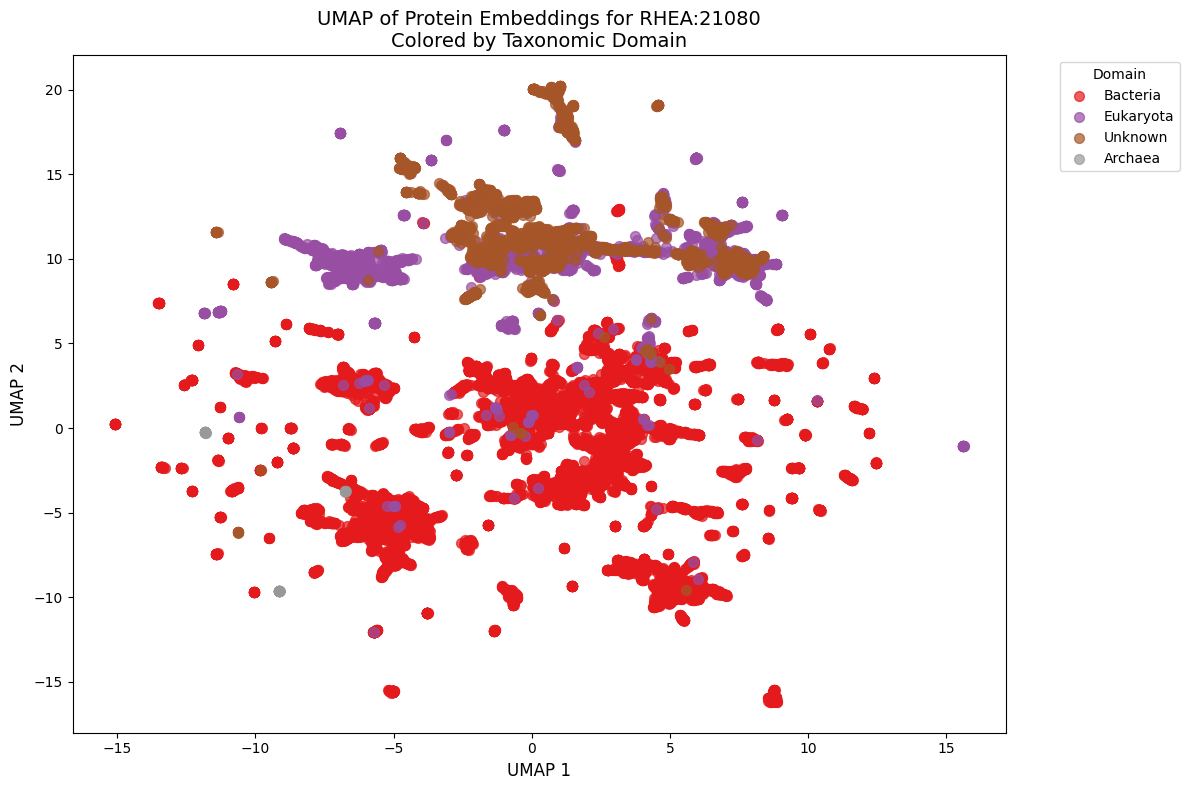

In [26]:
# Create visualization
if "umap_x" in df.columns:
    # Get unique domains and create color map
    domains = df["domain_name"].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(domains)))
    color_map = dict(zip(domains, colors))

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot each domain
    for domain in domains:
        mask = df["domain_name"] == domain
        ax.scatter(
            df.loc[mask, "umap_x"],
            df.loc[mask, "umap_y"],
            c=[color_map[domain]],
            label=domain,
            alpha=0.7,
            s=50,
        )

    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)
    ax.set_title(
        f"UMAP of Protein Embeddings for RHEA:21080\nColored by Taxonomic Domain", fontsize=14
    )
    ax.legend(title="Domain", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
else:
    print("[yellow]UMAP not available - skipping visualization[/yellow]")


### 3.5 Final DataFrame with all data


In [27]:
# Display final DataFrame
print("[bold]Final DataFrame:[/bold]")
display_cols = ["protein_id", "protein_name", "seq_length", "species_name", "domain_name"]
if "umap_x" in df.columns:
    display_cols.extend(["umap_x", "umap_y"])

df[display_cols].head(10)


Final DataFrame:

,protein_id,protein_name,seq_length,species_name,domain_name,umap_x,umap_y
0,A0A009HMN2,S-adenosylmethionine synthase,369,Acinetobacter baumannii (strain 1295743),Bacteria,6.279761,2.275184
1,A0A009PJZ4,S-adenosylmethionine synthase,388,Acinetobacter baumannii 625974,Bacteria,6.270806,2.262564
2,A0A009SIA8,S-adenosylmethionine synthase,369,Acinetobacter baumannii 99063,Bacteria,6.278121,2.274743
3,A0A010QI30,S-adenosylmethionine synthase,401,Colletotrichum fioriniae PJ7,Eukaryota,-7.677392,10.515318
4,A0A010RSY6,S-adenosylmethionine synthase,396,Pseudomonas fluorescens HK44,Bacteria,-5.446733,-0.882459
5,A0A010Z1P9,S-adenosylmethionine synthase,398,Cryptosporangium arvum DSM 44712,Bacteria,-4.168554,-6.434457
6,A0A011MET9,S-adenosylmethionine synthase,389,Candidatus Accumulibacter adjunctus,Bacteria,-1.242839,0.513889
7,A0A011P517,S-adenosylmethionine synthase,383,Mannheimia granulomatis,Bacteria,1.783168,1.919225
8,A0A011Q966,S-adenosylmethionine synthase,388,Accumulibacter regalis,Bacteria,-1.306778,0.450821
9,A0A011QVP5,S-adenosylmethionine synthase,388,Candidatus Accumulibacter appositus,Bacteria,-1.406569,0.470664


In [28]:
# Summary statistics
print("[bold]Summary Statistics:[/bold]")
print(f"  Total proteins: {len(df)}")
print(f"  Unique species: {df['species_name'].nunique()}")
print(f"  Unique domains: {df['domain_name'].nunique()}")
print(f"  Avg sequence length: {df['seq_length'].mean():.1f} aa")


Summary Statistics:

Total proteins: 26726

Unique species: 18038

Unique domains: 4

Avg sequence length: 394.1 aa

---
## Cleanup

In [29]:
# Close database connections
await neo4j_driver.close()
await milvus_client.close()

print("[green]✓ Connections closed[/green]")


✓ Connections closed

---
## Summary

This notebook demonstrated:

1. **Python API Methods**
   - `Protein.get(id=...)` / `get(ids=[...])` - Direct node lookups
   - `Protein.get_filtered(ranges={...}, **filters)` - Filtered queries
   - `Protein.get_related(Taxon, id=..., direction="out")` - Relationship traversal
   - `Protein.count()` - Node counting

2. **Native Cypher Queries**
   - Same operations using raw Cypher for complex queries
   - Multi-hop traversals (Protein → Reaction → Molecule)

3. **Advanced Analysis**
   - Taxonomy hierarchy traversal to domain level
   - Vector retrieval from Milvus
   - UMAP visualization colored by taxonomic domain

The PyEED Python API provides a clean, type-safe interface for common queries while still allowing native Cypher for complex operations.
